# Logistic Regression : Binary Classification

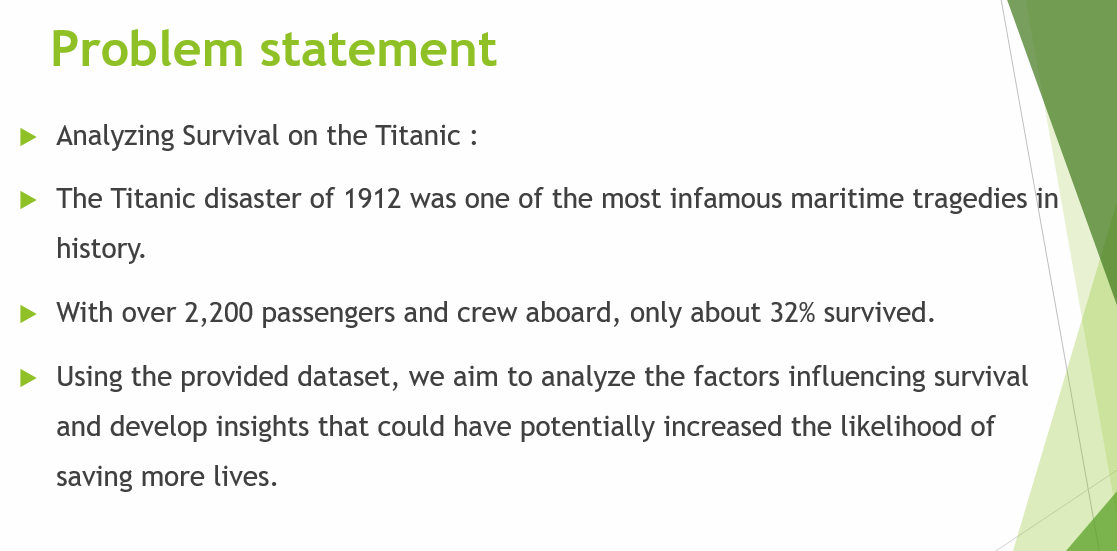

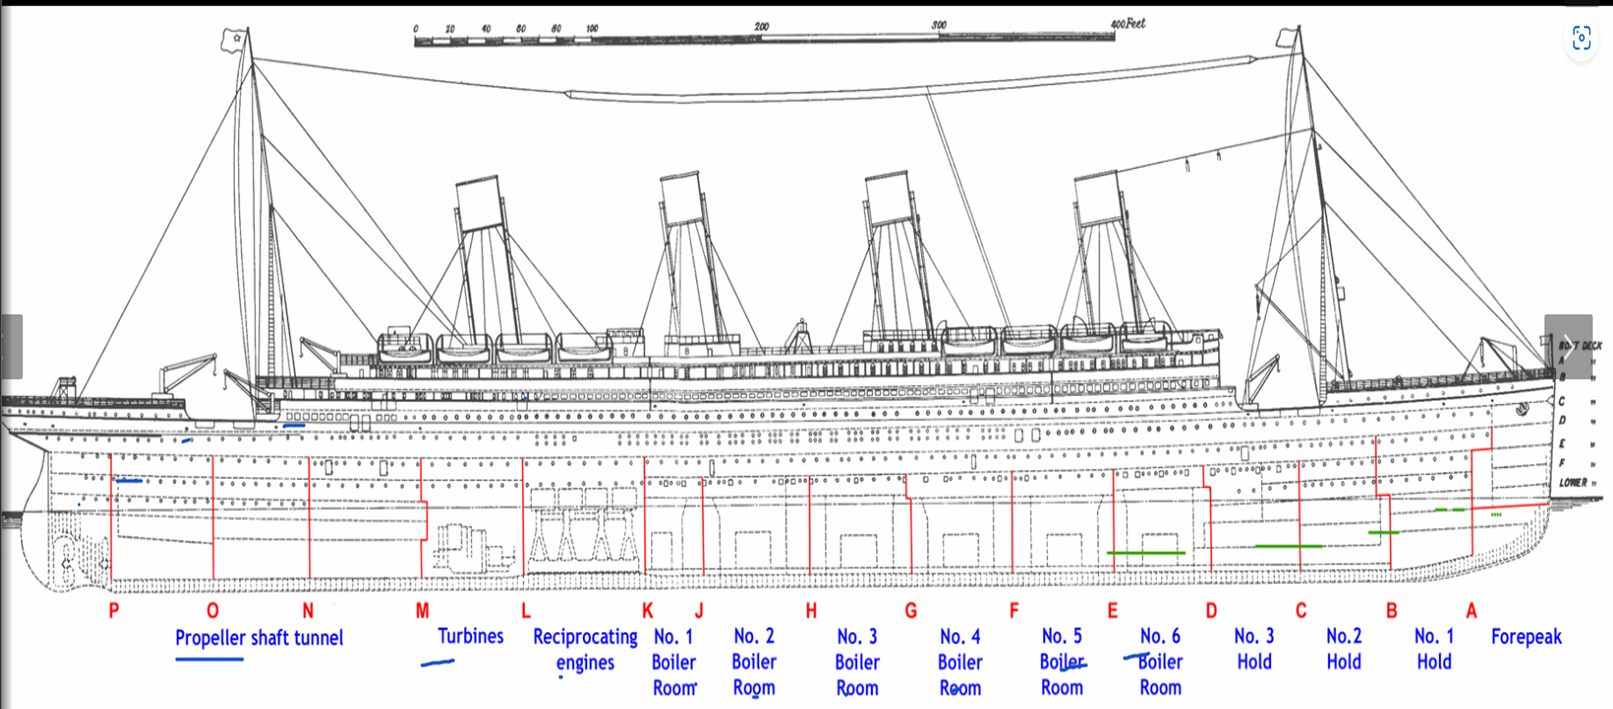

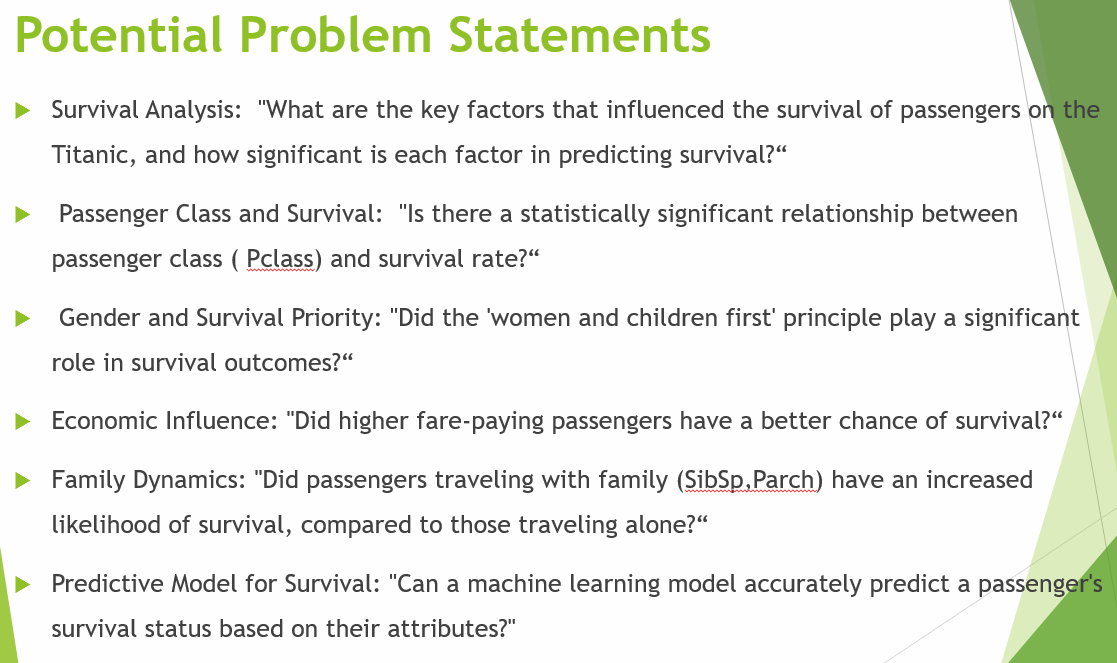

In [3]:
# Titanic data set
import os # where the path is
import numpy as np # mathematical calculation
import pandas as pd # data manipulation
import matplotlib.pyplot as plt # data visuliasation
import seaborn as sns # data visuliasation
sns.set  
%matplotlib inline 
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows',500)
pd.set_option('display.max_columns',50)
pd.set_option('display.width',1000)

In [4]:
df = pd.read_csv('titanic_train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

- ## Since cabin have 77% data , we can drop it along with 'PassengerId','Name','Ticket', 'Fare' as they are not relevant for survival

In [1]:
df = df.drop(['PassengerId','Name','Ticket', 'Fare','Cabin'],axis = 1)


NameError: name 'df' is not defined

In [10]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked'], dtype='object')

In [11]:
df.shape

(891, 7)

In [12]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Embarked     object
dtype: object

In [13]:
df.isnull().sum()/len(df)*100

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Embarked     0.224467
dtype: float64

- Age and Embarked has missing value: where Age is numerical data and Embarked is character type data.

In [14]:
df['Age'].describe()
# df[['Age']].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

- ## In case of Age Max = 80 ( means old age people are possible, also Min = 0.42(means infant also possible) 
- ## So We are assuming there is no outlier even the plot may show.
- ## therefore for missing handiling missing value we can go with median or mean.

<Axes: ylabel='Age'>

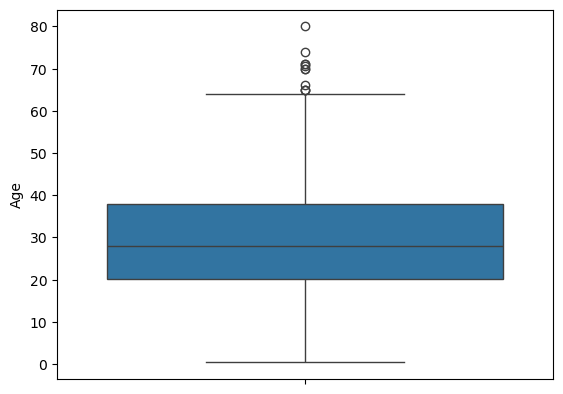

In [15]:
sns.boxplot(y = 'Age',data = df)

In [16]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 48.9+ KB


In [18]:
df[['Embarked']].value_counts()

Embarked
S           644
C           168
Q            77
Name: count, dtype: int64

In [19]:
df['Embarked'] = df['Embarked'].fillna('S')

In [20]:
#df['Embarked'].mode()

In [21]:
#df.Embarked.value_counts(dropna=False)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 48.9+ KB


- # Encoding: variables have data type object like 'Sex' and 'Embarkd'
- ## One-Hot Encoding
- What it does: Converts categorical variables into a series of binary columns (e.g., "male" -> [1, 0], "female" -> [0, 1]).
- When to use: This is typically the better approach for most machine learning algorithms, especially linear models and neural networks, as it avoids     implying any ordinal relationship.
- Example algorithms: Linear Regression, Logistic Regression, Neural Networks, SVMs.
- To use One Hot Encoding on the Sex column in your DataFrame, you can use the OneHotEncoder from sklearn.preprocessing
-  or the get_dummies function from pandas. 
- ## Label Encoding
-  What it does: Converts categorical values to numeric labels (e.g., "male" -> 0, "female" -> 1).
-  When to use: This is suitable for algorithms that can handle ordinal relationships between categories. However, it's generally not recommended for      categorical variables without a meaningful order, as it can introduce unintended ordinal relationships.
-  Example algorithms: Tree-based methods like Decision Trees, Random Forests, Gradient Boosting Machines can handle label encoded variables well.
-  

In [23]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

- ## We can do label encoding as there only two possibility. However OHE is best practice when there no ordinal issue.

In [24]:
# label encoder
# df['Sex'] = df['Sex'].astype('category')
# df['Sex'] = df['Sex'].cat.codes

from sklearn.preprocessing import OneHotEncoder

- ### Initialize the OneHotEncoder
encoder = OneHotEncoder()

- ### Fit and transform the data
one_hot_encoded = encoder.fit_transform(df[['Sex']]).toarray()

- ### Create a DataFrame with the one hot encoded columns
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Sex']))

- ### Concatenate the original DataFrame with the one hot encoded DataFrame
df = pd.concat([df, one_hot_df], axis=1)

df.head()


In [25]:
# If you want to drop original feature
#df = pd.get_dummies(df,columns = ['Sex'])
#df.head()

In [26]:
# if you want to keep original feature 
#dummies = pd.get_dummies(df[['Sex']], prefix=['Sex'], drop_first=True)

#df = pd.concat([df, dummies], axis=1)


In [27]:
df = pd.get_dummies(df,columns = ['Sex'], drop_first=True)


In [28]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Embarked,Sex_male
0,0,3,22.0,1,0,S,True
1,1,1,38.0,1,0,C,False
2,1,3,26.0,0,0,S,False
3,1,1,35.0,1,0,S,False
4,0,3,35.0,0,0,S,True


In [29]:
df = pd.get_dummies(df,columns = ['Embarked'], drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,True,False,True
1,1,1,38.0,1,0,False,False,False
2,1,3,26.0,0,0,False,False,True
3,1,1,35.0,1,0,False,False,True
4,0,3,35.0,0,0,True,False,True


In [30]:
df.shape

(891, 8)

In [31]:
df['Pclass'].unique()

array([3, 1, 2], dtype=int64)

In [32]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Sex_male    891 non-null    bool   
 6   Embarked_Q  891 non-null    bool   
 7   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(1), int64(4)
memory usage: 37.5 KB


In [34]:
df = pd.get_dummies(df,columns = ['Pclass'], drop_first=True)

df.head()

,Survived,Age,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,True,False,True,False,True
1,1,38.0,1,0,False,False,False,False,False
2,1,26.0,0,0,False,False,True,False,True
3,1,35.0,1,0,False,False,True,False,False
4,0,35.0,0,0,True,False,True,False,True


In [35]:
#df = df.astype(int)

- ##  In case of dummy variables: Drop the Ist dummy to avoid multicolinearity effect 


- ## In classification you no need to treat outliers
- ## In classification problem you to check whether data is balanced or not.
- ## If not balanced than balance it
- ## balancing is done only for dependent variable.

In [36]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [37]:
df.head()

,Survived,Age,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,22.0,1,0,True,False,True,False,True
1,1,38.0,1,0,False,False,False,False,False
2,1,26.0,0,0,False,False,True,False,True
3,1,35.0,1,0,False,False,True,False,False
4,0,35.0,0,0,True,False,True,False,True


- ## Since in this case twice of minority class is greater than majority class , we say data is balanced.

- ## Split the data in to dependent and independent variables

In [38]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

- ## Using df.loc 

In [39]:
x.head()

,Age,SibSp,Parch,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,22.0,1,0,True,False,True,False,True
1,38.0,1,0,False,False,False,False,False
2,26.0,0,0,False,False,True,False,True
3,35.0,1,0,False,False,True,False,False
4,35.0,0,0,True,False,True,False,True


In [40]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

- ### Assuming 'Column0' is the first column, and you want all rows and all columns except the first one
- x = df.loc[:, df.columns[1:]]

- ### Assuming 'Column0' is the first column and you want all rows of this column
- y = df.loc[:, df.columns[0]]
- y = df.loc[:, 'Survived']
- The main difference between loc and iloc in pandas lies in how they select data:

- ### loc: Selects data by labels (i.e., using row and column names).
- ### iloc: Selects data by integer position (i.e., using row and column indices).


- ## Split the data into train and test

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
#x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 42,stratify = y)

In [43]:
#x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 100,stratify = y)

In [44]:
#x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 150,stratify = y)

In [45]:
#x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 300,stratify = y)

In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 500,stratify = y)

### Building Model

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
x_train.dtypes


Age           float64
SibSp           int64
Parch           int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
Pclass_2         bool
Pclass_3         bool
dtype: object

In [49]:
#x_train = x_train.drop('Sex', axis=1)


In [50]:
logit = LogisticRegression()
logit.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


- ## Prediction

In [51]:
y_pred_train = logit.predict(x_train)
y_pred_test = logit.predict(x_test)

In [52]:
y_pred_train

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,

- ## Model Evaluation

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
print('Training_Accuracy_Score:',accuracy_score(y_train,y_pred_train))

Training_Accuracy_Score: 0.7935393258426966


In [55]:
print('Test_Accuracy_Score:',accuracy_score(y_test,y_pred_test))

Test_Accuracy_Score: 0.7988826815642458


- ## Accuracy is not a good measurement to measure model performance when data is imbalanced.
  

In [56]:
from sklearn.metrics import classification_report,confusion_matrix

In [57]:
print('\nTraining_Classification_Report:\n',classification_report(y_train,y_pred_train))


Training_Classification_Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       439
           1       0.75      0.69      0.72       273

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.78       712
weighted avg       0.79      0.79      0.79       712



In [58]:
print('\nTesting_Classification_Report:\n',classification_report(y_test,y_pred_test))


Testing_Classification_Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82       110
           1       0.69      0.86      0.77        69

    accuracy                           0.80       179
   macro avg       0.79      0.81      0.79       179
weighted avg       0.82      0.80      0.80       179



In [59]:
print('\nTraining_Confusion_Matrix:\n',confusion_matrix(y_train,y_pred_train))


Training_Confusion_Matrix:
 [[376  63]
 [ 84 189]]


In [60]:
print('\nTesting_Confusion_Matrix:\n',confusion_matrix(y_test,y_pred_test))


Testing_Confusion_Matrix:
 [[84 26]
 [10 59]]


In [61]:
#                      Predicted Negative   Predicted Positive
# Actual Negative         TN                    FP
# Actual Positive         FN                    TP

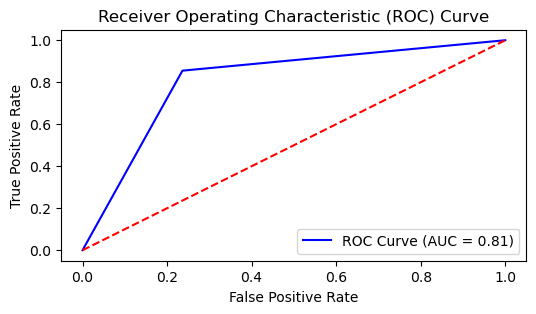

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_test)

# Plot the ROC curve
plt.figure(figsize=(6, 3))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [63]:
# crossvalidation

In [64]:
from sklearn.model_selection import cross_val_score
training_accuracy = cross_val_score(logit,x_train,y_train,cv=10)
#test_accuracy = cross_val_score(logit,x_test,y_test,cv=10)
print(training_accuracy.mean())
#print(test_accuracy.mean())

0.7836267605633802
